# WORKSHOP - 5: License Plate Detection using OpenCV and Haar Cascade Classifier
## NAME:HARSHITHA D
## REG NO:212224040110

In [1]:
# In[1]:

import cv2
import matplotlib.pyplot as plt
import os
import urllib.request

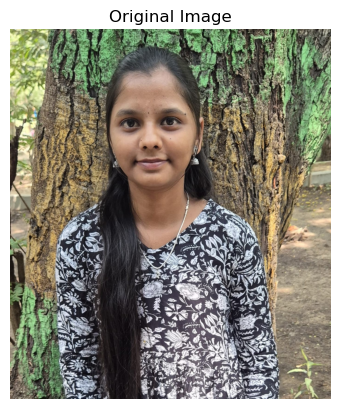

In [2]:
# In[2]:

# Step 1: Read and Display Input Image

image_path = 'HARR.jpeg'

image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(
        "Image not found. Please check the image path."
    )

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')
plt.show()

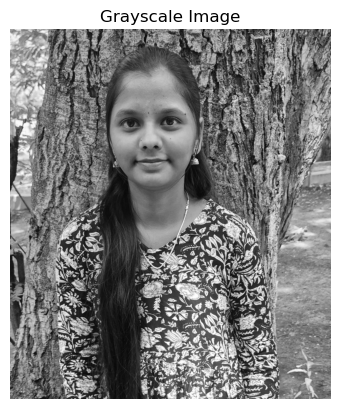

In [3]:
# In[3]:

# Step 2: Convert to Grayscale

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

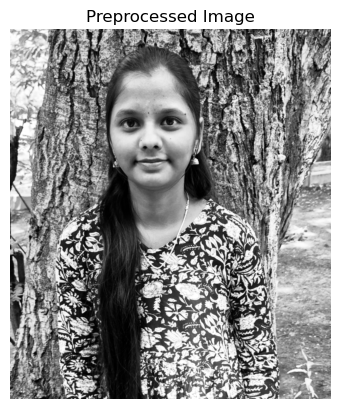

In [4]:
# In[4]:

# Step 3: Preprocessing

blurred = cv2.GaussianBlur(gray, (5, 5), 0)

equalized = cv2.equalizeHist(blurred)

plt.imshow(equalized, cmap='gray')
plt.title("Preprocessed Image")
plt.axis('off')
plt.show()

In [5]:
# In[5]:

# Step 4: Load Haar Cascade File

cascade_path = 'haarcascade_frontalface_default.xml'

if not os.path.exists(cascade_path):

    print("Cascade file not found. Downloading...")

    url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"

    urllib.request.urlretrieve(url, cascade_path)

    print("Download completed.")

face_cascade = cv2.CascadeClassifier(cascade_path)

Cascade file not found. Downloading...
Download completed.


In [6]:
# In[6]:

# Step 5: Detect Faces

faces = face_cascade.detectMultiScale(
    equalized,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

print("Total Faces Detected:", len(faces))

Total Faces Detected: 5


In [7]:
# In[7]:

# Step 6: Draw Rectangles and Save Faces

output = image.copy()

save_dir = "Detected_Faces"

os.makedirs(save_dir, exist_ok=True)

for i, (x, y, w, h) in enumerate(faces):

    cv2.rectangle(
        output,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        3
    )

    face_crop = image[y:y+h, x:x+w]

    save_path = f"{save_dir}/face_{i+1}.jpg"

    cv2.imwrite(save_path, face_crop)

if len(faces) > 0:

    print(f"{len(faces)} face(s) saved in '{save_dir}' folder.")

else:

    print("No faces detected.")

5 face(s) saved in 'Detected_Faces' folder.


In [8]:
# In[7]:

# Step 6: Draw Rectangles and Save Faces

output = image.copy()

save_dir = "Detected_Faces"

os.makedirs(save_dir, exist_ok=True)

for i, (x, y, w, h) in enumerate(faces):

    cv2.rectangle(
        output,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        3
    )

    face_crop = image[y:y+h, x:x+w]

    save_path = f"{save_dir}/face_{i+1}.jpg"

    cv2.imwrite(save_path, face_crop)

if len(faces) > 0:

    print(f"{len(faces)} face(s) saved in '{save_dir}' folder.")

else:

    print("No faces detected.")

5 face(s) saved in 'Detected_Faces' folder.


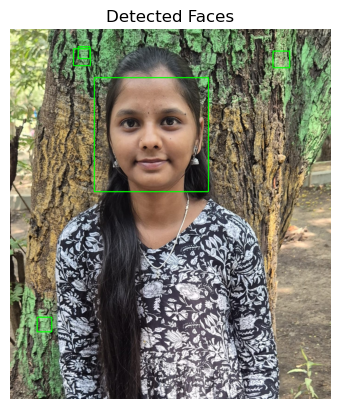

In [9]:
# In[8]:

# Step 7: Display Final Output

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Detected Faces")
plt.axis('off')
plt.show()